<a href="https://colab.research.google.com/github/matvey-gostev/Calculation-Of-Absolute-Permeability-Of-Rock-Based-On-Topological-Features/blob/main/Visualization_of_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Скачиваем библиотеку PyVista
Данная библиотека предоставляет инструменты для отрисовки 3-D моделей

In [10]:
pip install pyvista numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.3/204.3 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.6/145.6 MB 6.9 MB/s eta 0:00:00


# Подключаем необходимые библиотеки

In [32]:
import numpy as np
import pyvista as pv
from IPython.display import Image, display

# Функция отрисовки
Данная функция позволяет отрисовать изображение породы по трехмерному бинарному массиву данных

In [41]:
def visualize(data, file_name='rock_structure_1', rock_name='rock'):
  shape = data.shape

  # предобработка
  indices = np.argwhere(data == 1)                  # запоминаем все индексы в массиве породы, в которых есть материя
  if indices.shape[0] == 0:                         # проверяем на корректность данные
    raise ValueError("Порода пустая!")
  points = pv.PolyData(indices, force_float=False)  # по индексам создаем набор точек для отображения
  glyph = points.glyph(geom=pv.Cube(), scale=False, orient=False, factor=1.0)
                                                    # каждую точку превращаем в glyph - элемент визуализации
                                                    # форма glyph-ов - кубики, ориентированные вдоль осей координат

  # обозначение границ
  bounds = [0, shape[0]-1, 0, shape[1]-1, 0, shape[2]-1] # задаем границы участка визуализации
  cube_outline = pv.Cube(bounds=bounds)                  # создаём кубическую границу


  # создание изображения
  pv.set_jupyter_backend('static')                              # используем статическую отрисовку
  plotter = pv.Plotter(off_screen=True, window_size=[400, 400]) # отключаем отрисовку в интерактивном окне
                                                                # для предварительного сохранения в png
                                                                # задаем размеры изображения

  plotter.add_mesh(glyph, color='grey', show_edges=False, lighting=True, opacity=1.0) # добавляем к изображению glyph-ы породы
  plotter.add_mesh(cube_outline, style='wireframe', color='lightgray', line_width=2, opacity=0.5) # добавляем границы

  plotter.set_background('white')                                       # задаём цвет фона
  plotter.camera_position = [(350, 320, 200), (64, 64, 64), (0, 0, 1)]  # устанавливаем удобную точку зрения
  plotter.add_title(rock_name, font_size=10)

  # сохранение изображения и отображение
  img_path = '/tmp/' + file_name + '.png'         # сохраняем картинку под нужным названием
  plotter.screenshot(img_path)  # копируем изображение из файла
  display(Image(img_path))      # отображаем в окне вывода

# Пример

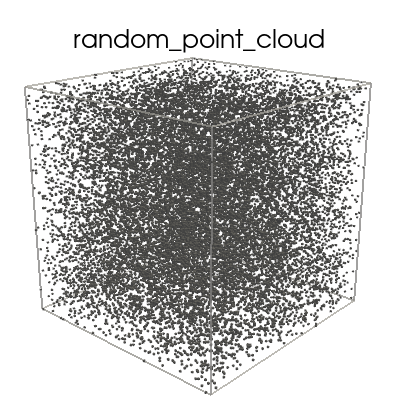

In [42]:
shape = (128, 128, 128)                                                   # размер куба
data = np.random.choice([0, 1], size=shape, p=[0.99, 0.01]).astype(bool)  # рандомно заполним пространство

visualize(data, 'example_1', 'random_point_cloud')                        # отрисовываем